In [3]:
! pwd

/Users/trixiesouthwood/Downloads/research/moose-wolves-sheaf/two-way


### Netlist Sheaf

In [4]:
import numpy as np
import pysheaf as ps
import scipy
import scipy.linalg

class NetlistSheaf(ps.Sheaf):
    def __init__(self, parts, nets, **kwargs):
        '''
Construct a netlist sheaf using a dictionary of `parts` and `nets`.  
Additional optional arguments accepted as `**kwargs`, so that these can be used as parameters as the sheaf is being built.  

> [!CAUTION]
> This function uses `eval()` to unpack and build Python expressions from strings.  You have been warned; sanitize your input!

Each part is named, and has fields:
* `data_dimension`, 
* `bounds` (optional), 
* `ports`.

The `ports` field is a dictionary naming each port, and associating a string that defines a function for the corresponding restriction map.  

Example:
```
{ "AND2" : { "data_dimension" : 2,
	     "bounds" : "[(0,1)]*2",
	     "ports" : { "IN1" : "lambda x: x[0]",
		       "IN2" : "lambda x: x[1]",
		       "OUT" : "lambda x: x[0]*x[1]" }},
...}
```

Each net is named, and has fields:
* `data_dimension`,
* `bounds` (optional),
* `value` (optional; NB: parsed with `eval()`),
* `optimize` (optional; anything not integer `0` is `True`; default = `True`),
* `constraint` (optional; 'equality' -> `pysheaf.CellConstraintType.EQUALITY`, 'inequality' -> `pysheaf.CellConstraintType.INEQUALITY`, anything else is `pysheaf.CellConstraintType.NONE`)
* `connections`.
Subsequently, `connections` is a list of dictionaries, each one has a `part` and `port` field, which index into the `parts` dictionary above.

```
Example
{
    "A": {
	"data_dimension" : 1,
	"bounds" : "[(0,1)]",
	"connections" : [
	       { "part" : "AND2",
		 "port" : "IN1"}
	   ]
    },
...}
```

> [!TIP]
> The default behavior is that all parts are optimization cells, and that no nets are optimization cells.
        '''
        
        ps.Sheaf.__init__(self)

        self.mNumpyNormType=2

        # First, build the parts (lower level of poset)
        for k,v in parts.items():
            if isinstance(v['data_dimension'],int):
                ddim = v['data_dimension']
            else:
                ddim = eval(v['data_dimension'])
                
            self.AddCell(k,
                         ps.Cell('part',
                                 dataDimension = ddim))
                
            self.GetCell(k).SetDataAssignment(ps.Assignment('part',np.zeros((ddim,))))
            self.GetCell(k).mOptimizationCell = True

        # Next, build the nets (upper level of poset)
        for k,v in nets.items():
            if isinstance(v['data_dimension'],int):
                ddim = v['data_dimension']
            else:
                ddim = eval(v['data_dimension'])

            self.AddCell(k,
                         ps.Cell('net',
                                 dataDimension = ddim))
            
            try:
                self.GetCell(k).SetDataAssignment(ps.Assignment('net',eval(v['value'])))
            except KeyError:
                self.GetCell(k).SetDataAssignment(ps.Assignment('net',np.zeros((ddim,))))

            try:
                self.GetCell(k).mOptimizationCell = (v['optimize']!=0)
            except KeyError:
                pass

            try:
                if v['constraint'] == 'inequality':
                    self.GetCell(k).mConstraintType = ps.CellConstraintType.INEQUALITY
                elif v['constraint'] == 'equality':
                    self.GetCell(k).mConstraintType = ps.CellConstraintType.EQUALITY
            except KeyError:
                pass

            # Connect each part in this net
            for vp in v['connections']:
                part=vp['part']
                port=vp['port']
                self.AddCoface(part,k,
                               ps.Coface('part','net',
                                         eval(parts[part]['ports'][port])))
        return

In [5]:
import csv
import json
import sys
import numpy as np
import scipy.linalg
import networkx as nx
import pysheaf as ps
import matplotlib.pyplot as plt
sys.path.append('/Users/trixiesouthwood/Downloads/research/netlist-sheaf')
import netlist_sheaf
import numpy.random
import numpy.polynomial
from collections import defaultdict

In [6]:
### Example based upon Figure 4 in
# Thorson et al., "Dynamic structural equation models synthesize ecosystem dynamics constrained by ecological mechanisms", DOI: 10.1111/2041-210X.14289
#
# This model uses the netlist sheaf construction.

import csv
import json
import numpy as np
import scipy.linalg
import pysheaf as ps
import matplotlib.pyplot as plt
import netlist_sheaf
from collections import defaultdict

# Names in the Thorson data disagree with their paper
names_dict={
    "wolves" : "wolves",
    "moose" : "moose"
    }

def lag_fcn(npts,ar,x):
    '''Convenience function for building lag matrices'''
    if ar:
        return scipy.linalg.toeplitz(np.concatenate(([0],x[0:ar],np.zeros((npts-ar-1,)))),np.zeros((npts,)))
    else: # Disable autoregression
        return np.eye(npts)

# Load the sheaf structure
parts=json.load(open('/Users/trixiesouthwood/Downloads/research/two_way_parts_copy.json'))
parts

{'wolves-block': {'data_dimension': "kwargs['npts']+2",
  'ports': {'in': 'lambda x: x[2:]',
   'crop': "lambda x,ar=kwargs['ar']: x[ar+2:]",
   'out': 'lambda x: x[0]+x[1]*x[2:]',
   'pc': 'lambda x: x[1]',
   'constant': 'lambda x: x[0]'}},
 'moose-block': {'data_dimension': "kwargs['npts']+2",
  'ports': {'in': 'lambda x: x[2:]',
   'crop': "lambda x,ar=kwargs['ar']: x[ar+2:]",
   'out': 'lambda x: x[0]+x[1]*x[2:]',
   'pc': 'lambda x: x[1]',
   'constant': 'lambda x: x[0]'}},
 'moose-lag': {'data_dimension': "kwargs['npts']+kwargs['ar']",
  'ports': {'in': "lambda x,npts=kwargs['npts'],ar=kwargs['ar']: x[ar:]",
   'out': "lambda x,npts=kwargs['npts'],ar=kwargs['ar'],lag_fcn=kwargs['lag_fcn']: np.dot(lag_fcn(npts,ar,x),x[ar:])[ar:]"}},
 'wolves-lag': {'data_dimension': "kwargs['npts']+kwargs['ar']",
  'ports': {'in': "lambda x,npts=kwargs['npts'],ar=kwargs['ar']: x[ar:]",
   'out': "lambda x,npts=kwargs['npts'],ar=kwargs['ar'],lag_fcn=kwargs['lag_fcn']: np.dot(lag_fcn(npts,ar,x),x[a

In [7]:
nets=json.load(open('/Users/trixiesouthwood/Downloads/research/two_way_nets_copy.json'))
nets

{'moose': {'data_dimension': "kwargs['npts']",
  'optimize': 1,
  'connections': [{'part': 'wolves-block', 'port': 'in'},
   {'part': 'moose-lag', 'port': 'in'},
   {'part': 'moose-block', 'port': 'out'}]},
 'wolves': {'data_dimension': "kwargs['npts']",
  'optimize': 1,
  'connections': [{'part': 'wolves-block', 'port': 'out'},
   {'part': 'moose-block', 'port': 'in'},
   {'part': 'wolves-lag', 'port': 'in'}]},
 'moose-pc': {'data_dimension': 1,
  'value': '0.6',
  'optimize': 1,
  'constraint': 'equality',
  'connections': [{'part': 'wolves-block', 'port': 'pc'}]},
 'wolves-pc': {'data_dimension': 1,
  'value': '0.6',
  'optimize': 1,
  'constraint': 'equality',
  'connections': [{'part': 'moose-block', 'port': 'pc'}]},
 'moose-lagvar': {'data_dimension': "kwargs['npts']-kwargs['ar']",
  'optimize': 1,
  'connections': [{'part': 'wolves-block', 'port': 'crop'},
   {'part': 'moose-lag', 'port': 'out'}]},
 'wolves-lagvar': {'data_dimension': "kwargs['npts']-kwargs['ar']",
  'optimize':

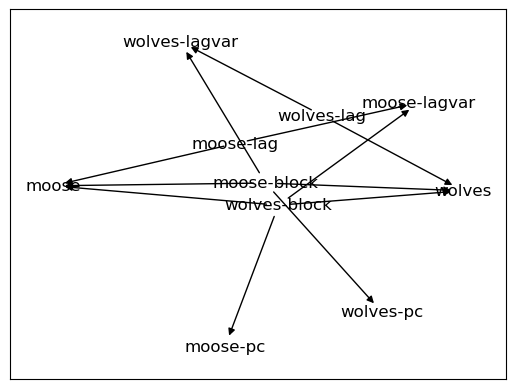

In [8]:
######enum code from chat 

from enum import Enum

# Temporary patch for missing enum
class CellConstraintType(Enum):
    EQUALITY = 0
    INEQUALITY = 1

ps.CellConstraintType = CellConstraintType



startyear = 1959
npts = 61
ar = 0
shf = netlist_sheaf.NetlistSheaf(parts,nets,npts=npts,ar=ar,lag_fcn=lag_fcn)

pos=nx.layout.spring_layout(shf)
nx.draw_networkx_labels(shf,pos)
nx.draw_networkx_edges(shf,pos)
plt.show()

# Load the data; adding in new cells to house the known values
measurements = defaultdict(list)
with open('/Users/trixiesouthwood/Downloads/research/log_isle_royal_data.csv') as fp:
    reader = csv.DictReader(fp, delimiter = ',')
    idx = 0
    for row in reader:
        for data_name,sheaf_name in names_dict.items():
            if row[data_name] != 'NA':
                year = startyear+idx
                datum = str(year) + "-" + sheaf_name
                value = float(row[data_name])

                measurements[sheaf_name].append((year,value))
                
                shf.AddCell(datum, ps.Cell('datum',dataDimension=1))
                shf.GetCell(datum).SetDataAssignment(ps.Assignment('datum', np.array([value])))
                shf.AddCoface(sheaf_name,datum,
                              ps.Coface('net','datum', lambda x,idx=idx : x[idx] ))
        
        idx = idx + 1

# Load in DSEM predictions
dsem_values = defaultdict(list)
with open('/Users/trixiesouthwood/Downloads/research/wolf_moose_dsem.csv') as fp:   
    reader = csv.DictReader(fp, delimiter = ',')
    idx = 0
    for row in reader:
        for data_name,sheaf_name in names_dict.items():
            if row[data_name] != 'NA':
                year = startyear+idx
                datum = str(year) + "-" + sheaf_name
                value = float(row[data_name])

                dsem_values[sheaf_name].append((year,value))        
        idx = idx + 1
    # functions 

===
Consistency radius before optimization: 116.70164182756969
Optimizing...
Consistency radius after optimization: 4.925548505414726
===
Path coefficients:
---
moose-pc : [-2.98665601]
wolves-pc : [-0.29863571]
===
Offsets:
---
wolves-block : 23.330389993390334
moose-block : [ 7.70453807 -0.29749755]
===
Autoregressive cofficients:
---
wolves : []
moose : []

All stalks
---
wolves-block : Star local consistency radius: 3.580607138062326
- -
wolves-block : [23.33038999 -2.98614315  6.75130271  6.72822852  6.72985129  6.71795826
  6.76276678  6.68908503  6.66959245  6.69628011  6.7624302   6.77396327
  6.87348113  6.85689711  6.83941986  6.80337379  6.78815866  6.71097329
  6.62153259  6.59351545  6.65689091  6.59529655  6.5755217   6.52117616
  6.67050746  6.89898355  6.75828028  6.75786642  6.78953729  6.82218621
  6.89200956  6.98495912  6.99838235  6.93684833  7.01768433  7.03172826
  7.01347595  6.94734278  6.97084431  6.89009886  6.75454941  6.91812989
  6.75365134  6.71348109  6.

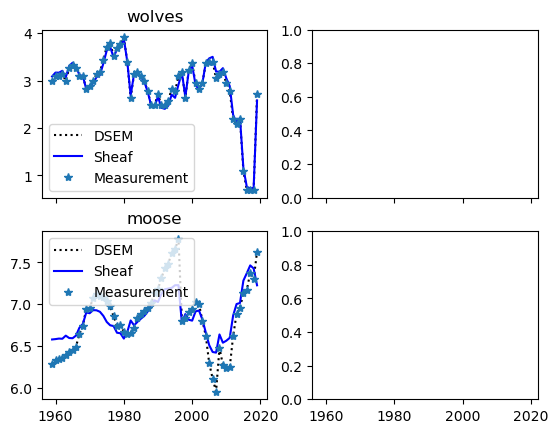

In [9]:
for c in shf.GetCellIndexList():
    shf.MaximallyExtendCell(c)

print('===')
print("Consistency radius before optimization: {}".format(shf.ComputeConsistencyRadius()))

print('Optimizing...')
shf.FuseAssignment()

print("Consistency radius after optimization: {}".format(shf.ComputeConsistencyRadius()))

print('===')
print("Path coefficients:") 
print('---')

for c in shf.GetCellIndexList():
    if "-pc" in c:
        print("{} : {}".format(c,shf.GetCell(c).mDataAssignment.mValue))

print('===')
print("Offsets:")
print('---')

for c in shf.GetCellIndexList():
    if c == 'moose-block':
        print("{} : {}".format(c,shf.GetCell(c).mDataAssignment.mValue[0:2]))
    elif "-block" in c:
        print("{} : {}".format(c,shf.GetCell(c).mDataAssignment.mValue[0]))

print('===')
print("Autoregressive cofficients:")
print('---')

for data_name,sheaf_name in names_dict.items():
    try:
        print("{} : {}".format(sheaf_name,shf.GetCell(sheaf_name + "-lag").mDataAssignment.mValue[0:ar]))
    except KeyError:
        pass


print('')
print('==========')
print('All stalks')
print('---')
for c in shf.GetCellIndexList():
    print("{} : Star local consistency radius: {}".format(c,shf.ComputeStarLocalConsistencyRadius(c)))
    print("- -")
    print("{} : {}".format(c,shf.GetCell(c).mDataAssignment.mValue))

years=[startyear + year for year in range(npts)]

fig = plt.figure()
axes = fig.subplots(2,2, sharex='all')
row = 0
col = 0
for data_name,sheaf_name in names_dict.items():
    axes[row,col].plot([x for x,y in dsem_values[sheaf_name]],[y for x,y in dsem_values[sheaf_name]],'k:',label='DSEM')
    axes[row,col].plot(years,shf.GetCell(sheaf_name).mDataAssignment.mValue,'b',label='Sheaf')
    axes[row,col].plot([x for x,y in measurements[sheaf_name]],[y for x,y in measurements[sheaf_name]],'*',label='Measurement')
    axes[row,col].set_title(sheaf_name)
    axes[row,col].legend()

    row += 1
    if row > 2:
        row = 0
        col += 1

plt.show()

### Sliding Sheaf

===
Consistency radius before optimization: 47.78313583269126
Optimizing...
Consistency radius after optimization: 0.6723398306580584
===
Path coefficients:
---
moose-pc : [-0.42131418]
wolves-pc : [-2.14773438]
===
Offsets:
---


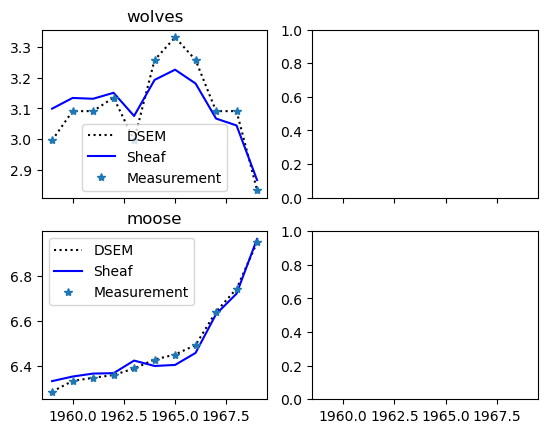

===
Consistency radius before optimization: 51.47639767124135
Optimizing...
Consistency radius after optimization: 0.7624962464936366
===
Path coefficients:
---
moose-pc : [-2.03559454]
wolves-pc : [-0.45689756]
===
Offsets:
---


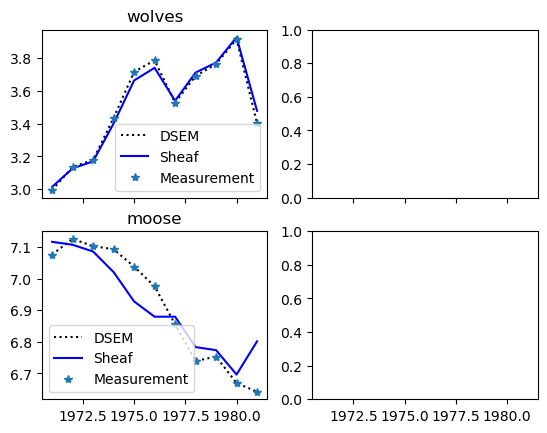

===
Consistency radius before optimization: 49.795589568406534
Optimizing...
Consistency radius after optimization: 0.7590937728088212
===
Path coefficients:
---
moose-pc : [-1.69478874]
wolves-pc : [-0.56115693]
===
Offsets:
---


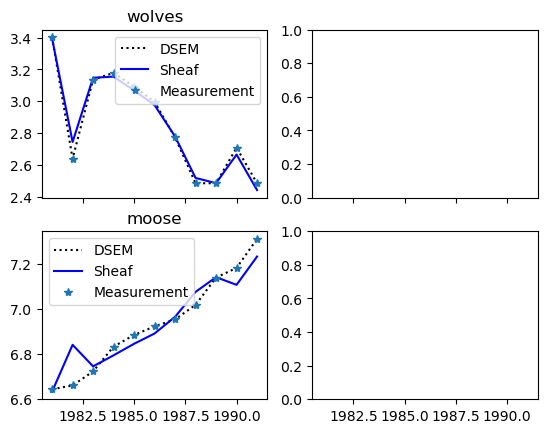

===
Consistency radius before optimization: 51.83617714297739
Optimizing...
Consistency radius after optimization: 1.4322453896782763
===
Path coefficients:
---
moose-pc : [-0.62420024]
wolves-pc : [-1.34615372]
===
Offsets:
---


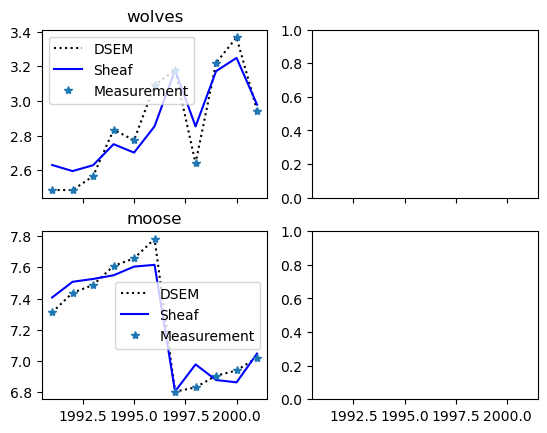

===
Consistency radius before optimization: 47.561368468466085
Optimizing...
Consistency radius after optimization: 1.1353173416451035
===
Path coefficients:
---
moose-pc : [-0.30895065]
wolves-pc : [-2.89865564]
===
Offsets:
---


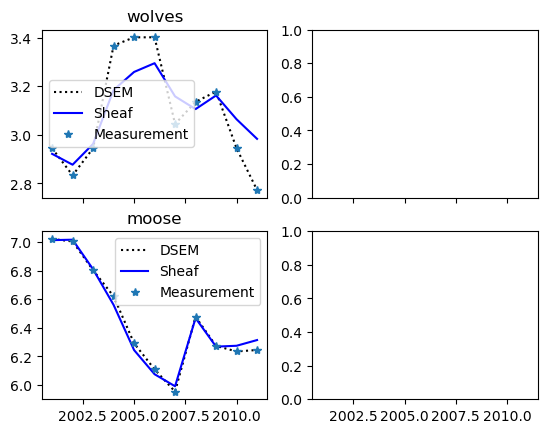

===
Consistency radius before optimization: 43.75195835965486
Optimizing...
Consistency radius after optimization: 2.2580278172973163
===
Path coefficients:
---
moose-pc : [10.28388907]
wolves-pc : [0.02234303]
===
Offsets:
---


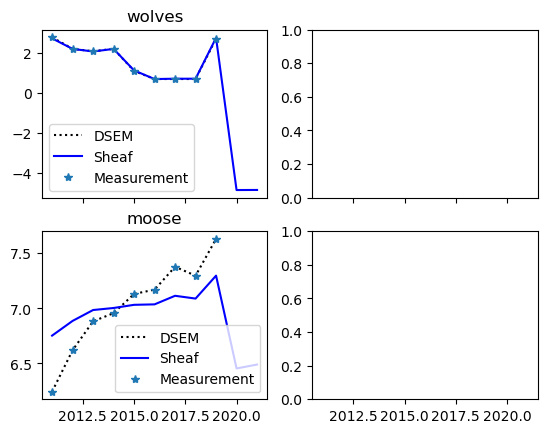

In [10]:
# sliding sheaf code that does work 

from enum import Enum

class CellConstraintType(Enum):
    EQUALITY = 0
    INEQUALITY = 1

ps.CellConstraintType = CellConstraintType

consistency_radius = []

overlap = 2     # how many years the sheaf overlap 
length = 10     # how many years long is each sheaf 
origin_year = 1959   # year data starts 
final_year = 2019
n_sheafs = int((final_year - origin_year) / length) # number of sheafs 

for n in range(0, n_sheafs): 
    if n == 0:
        startyear = origin_year 
    else: 
        startyear = origin_year + (10 * n) + overlap
    
    endyear = startyear + length 
    npts = endyear - startyear + 1   # has to be endyear - startyear + 1 
    ar = 0
    shf = netlist_sheaf.NetlistSheaf(parts,nets,npts=npts,ar=ar,lag_fcn=lag_fcn)
    
    measurements = defaultdict(list)
    with open('/Users/trixiesouthwood/Downloads/research/log_isle_royal_data.csv') as fp:
        reader = csv.DictReader(fp, delimiter = ',')
        idx = 0
        for row in reader:
            for data_name,sheaf_name in names_dict.items():
                if row[data_name] != 'NA':
                    year = origin_year + idx 
                    if year > endyear:
                        break 
                        
                if year >= startyear: 
                    
                        datum = str(year) + "-" + sheaf_name
                        value = float(row[data_name])
        
                        measurements[sheaf_name].append((year,value))
                        
                        shf.AddCell(datum, ps.Cell('datum',dataDimension=1))
                        shf.GetCell(datum).SetDataAssignment(ps.Assignment('datum', np.array([value])))
                        shf.AddCoface(sheaf_name,datum,
                                      ps.Coface('net','datum', lambda x,i  = year - startyear: x[i] ))
                
            idx = idx + 1
    
    # Load in DSEM predictions
    dsem_values = defaultdict(list)
    with open('/Users/trixiesouthwood/Downloads/research/wolf_moose_dsem.csv') as fp:   
        reader = csv.DictReader(fp, delimiter = ',')
        idx = 0
        for row in reader:
            for data_name,sheaf_name in names_dict.items():
                if row[data_name] != 'NA':
                    year = origin_year + idx 
                    
                    if year > endyear:
                        break 
                
                    if year >= startyear: 
    
                        datum = str(year) + "-" + sheaf_name
                        value = float(row[data_name])
        
                        dsem_values[sheaf_name].append((year,value))        
           
            idx = idx + 1


    for c in shf.GetCellIndexList():
        shf.MaximallyExtendCell(c)
    
    print('===')
    print("Consistency radius before optimization: {}".format(shf.ComputeConsistencyRadius()))
    
    print('Optimizing...')
    shf.FuseAssignment()
    
    print("Consistency radius after optimization: {}".format(shf.ComputeConsistencyRadius()))

    consistency_radius.append(shf.ComputeConsistencyRadius())
        
    print('===')
    print("Path coefficients:") 
    print('---')
    
    for c in shf.GetCellIndexList():
        if "-pc" in c:
            print("{} : {}".format(c,shf.GetCell(c).mDataAssignment.mValue))
    
    print('===')
    print("Offsets:")
    print('---')
    
    years=[startyear + year for year in range(npts)]
    
    fig = plt.figure()
    axes = fig.subplots(2,2, sharex='all')
    row = 0
    col = 0
    for data_name,sheaf_name in names_dict.items():
        axes[row,col].plot([x for x,y in dsem_values[sheaf_name]],[y for x,y in dsem_values[sheaf_name]],'k:',label='DSEM')
        axes[row,col].plot(years,shf.GetCell(sheaf_name).mDataAssignment.mValue,'b',label='Sheaf')
        axes[row,col].plot([x for x,y in measurements[sheaf_name]],[y for x,y in measurements[sheaf_name]],'*',label='Measurement')
        axes[row,col].set_title(sheaf_name)
        axes[row,col].legend()
    
        row += 1
        if row > 2:
            row = 0
            col += 1
    
    plt.show()
    
        




Text(0.5, 1.0, 'Consistency Radius')

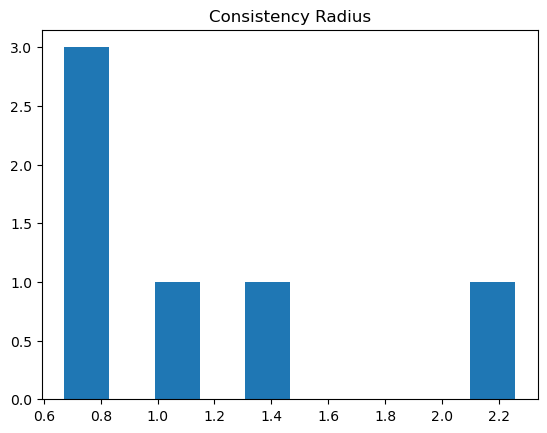

In [11]:
plt.hist(consistency_radius) 
plt.title("Consistency Radius")

### Sliding sheaf length loop

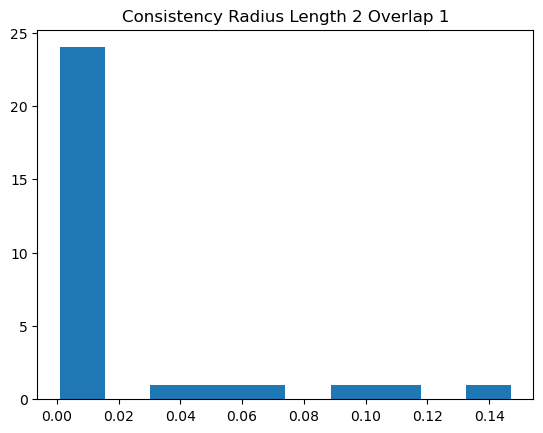

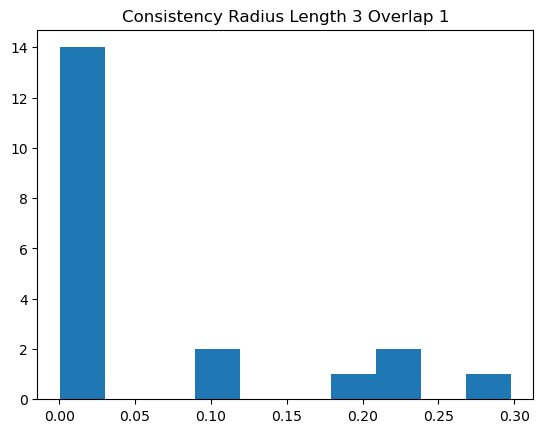

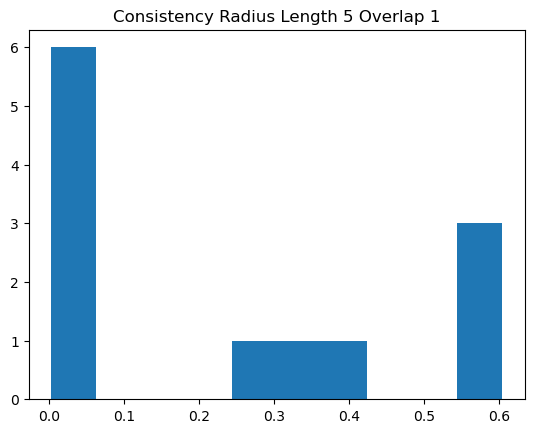

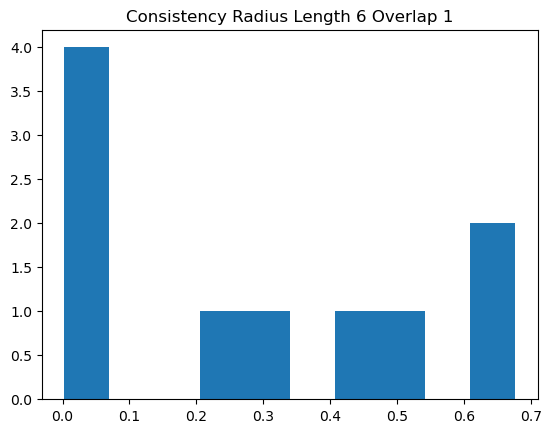

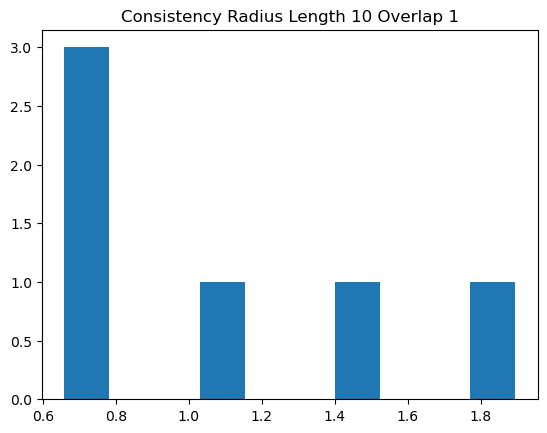

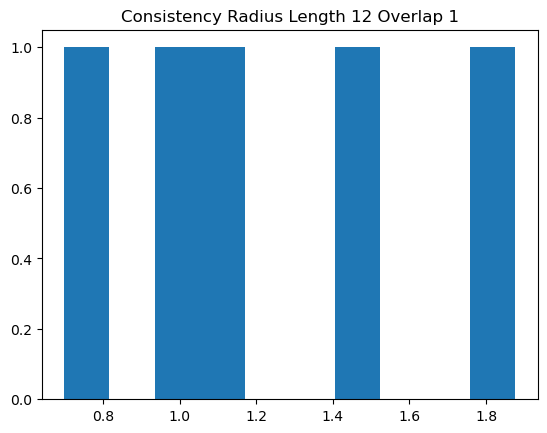

In [17]:

lengths = [2, 3, 5, 6, 10, 12]

for l in lengths: 
    
    from enum import Enum
    
    class CellConstraintType(Enum):
        EQUALITY = 0
        INEQUALITY = 1
    
    ps.CellConstraintType = CellConstraintType
    
    consistency_radius = []
    
    overlap = 1     # how many years the sheaf overlap 
    length = l     # how many years long is each sheaf 
    origin_year = 1959   # year data starts 
    final_year = 2019
    n_sheafs = int((final_year - origin_year) / length) # number of sheafs 
    
    for n in range(0, n_sheafs): 
        if n == 0:
            startyear = origin_year 
        else: 
            startyear = origin_year + (10 * n) + overlap
        
        endyear = startyear + length 
        npts = endyear - startyear + 1   # has to be endyear - startyear + 1 
        ar = 0
        shf = netlist_sheaf.NetlistSheaf(parts,nets,npts=npts,ar=ar,lag_fcn=lag_fcn)
        
        measurements = defaultdict(list)
        with open('/Users/trixiesouthwood/Downloads/research/log_isle_royal_data.csv') as fp:
            reader = csv.DictReader(fp, delimiter = ',')
            idx = 0
            for row in reader:
                for data_name,sheaf_name in names_dict.items():
                    if row[data_name] != 'NA':
                        year = origin_year + idx 
                        if year > endyear:
                            break 
                            
                    if year >= startyear: 
                        
                            datum = str(year) + "-" + sheaf_name
                            value = float(row[data_name])
            
                            measurements[sheaf_name].append((year,value))
                            
                            shf.AddCell(datum, ps.Cell('datum',dataDimension=1))
                            shf.GetCell(datum).SetDataAssignment(ps.Assignment('datum', np.array([value])))
                            shf.AddCoface(sheaf_name,datum,
                                          ps.Coface('net','datum', lambda x,i  = year - startyear: x[i] ))
                    
                idx = idx + 1
        
        # Load in DSEM predictions
        dsem_values = defaultdict(list)
        with open('/Users/trixiesouthwood/Downloads/research/wolf_moose_dsem.csv') as fp:   
            reader = csv.DictReader(fp, delimiter = ',')
            idx = 0
            for row in reader:
                for data_name,sheaf_name in names_dict.items():
                    if row[data_name] != 'NA':
                        year = origin_year + idx 
                        
                        if year > endyear:
                            break 
                    
                        if year >= startyear: 
        
                            datum = str(year) + "-" + sheaf_name
                            value = float(row[data_name])
            
                            dsem_values[sheaf_name].append((year,value))        
               
                idx = idx + 1
    
    
        for c in shf.GetCellIndexList():
            shf.MaximallyExtendCell(c)
        
    
        shf.FuseAssignment()
        
        consistency_radius.append(shf.ComputeConsistencyRadius())
        
        years=[startyear + year for year in range(npts)]
    
    
    plt.hist(consistency_radius) 
    plt.title(f"Consistency Radius Length {l} Overlap 1")
    plt.show()
    
            
    
    


### Sliding sheaf length and overlap loop

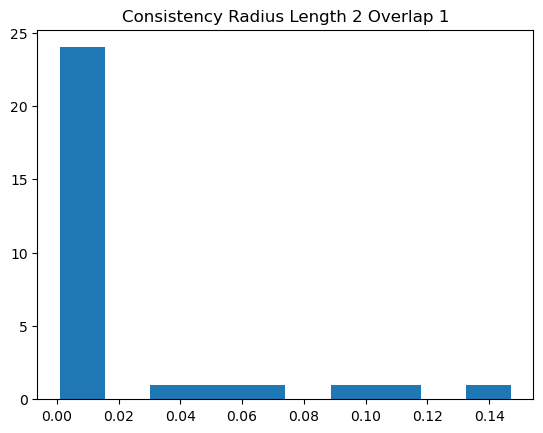

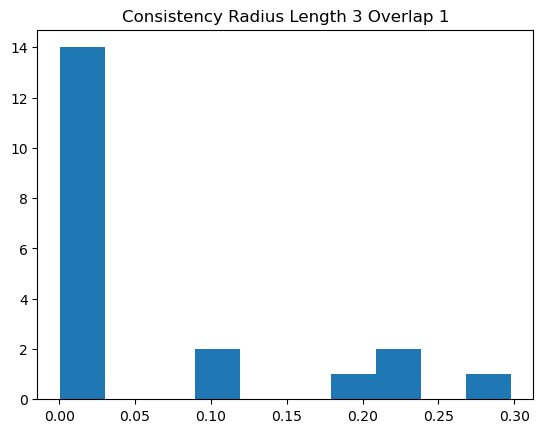

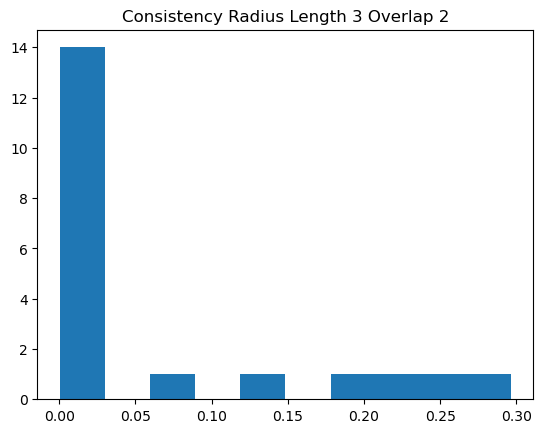

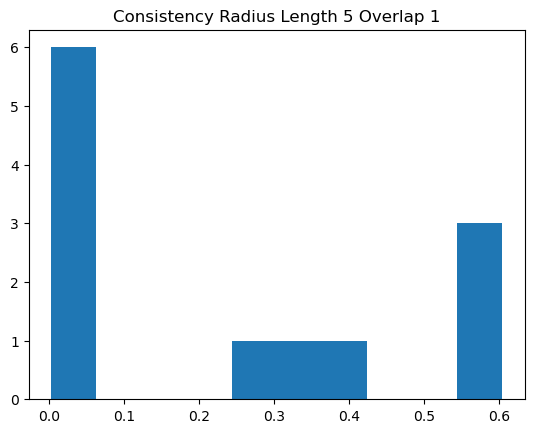

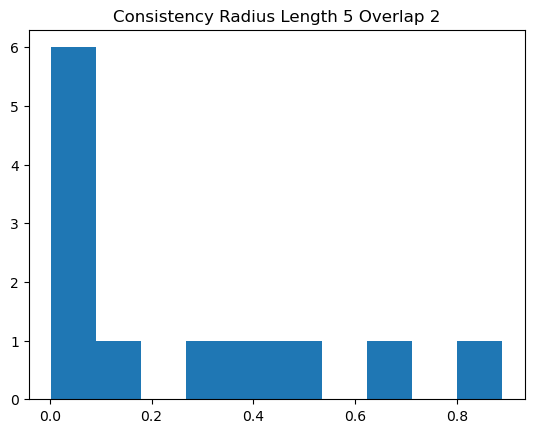

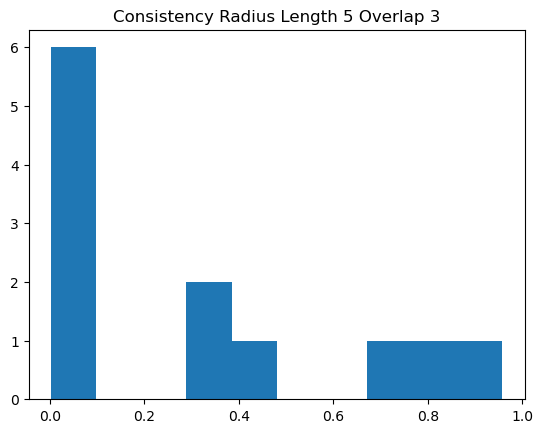

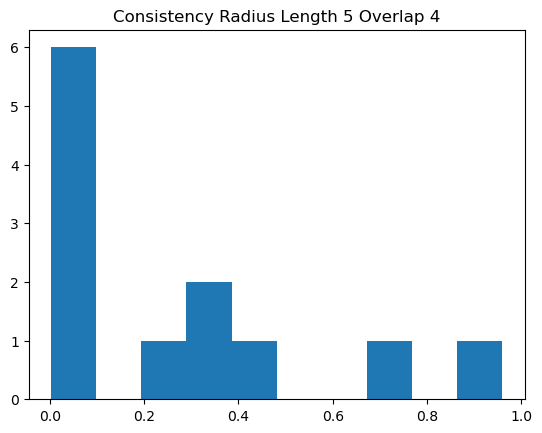

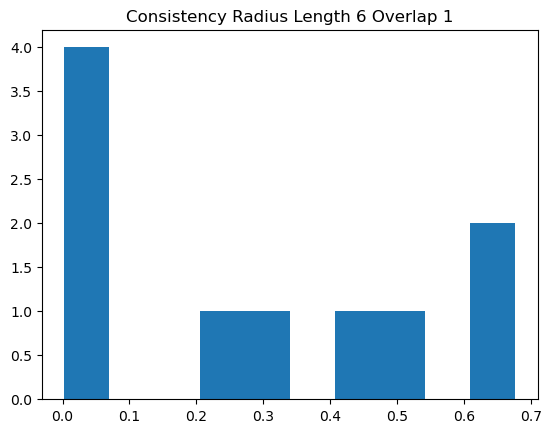

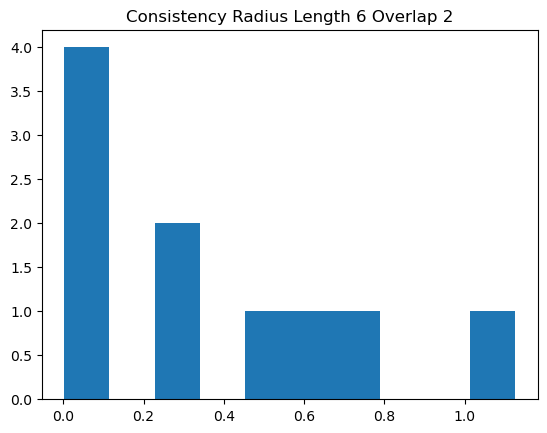

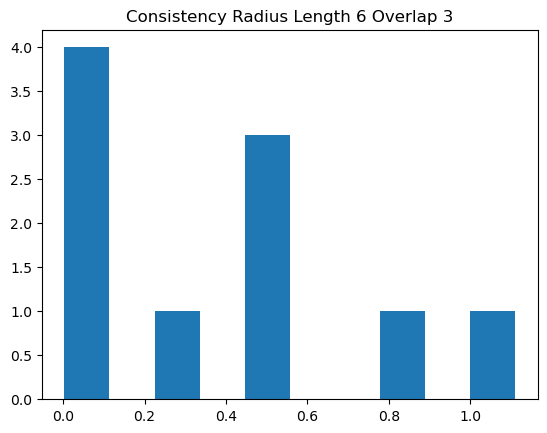

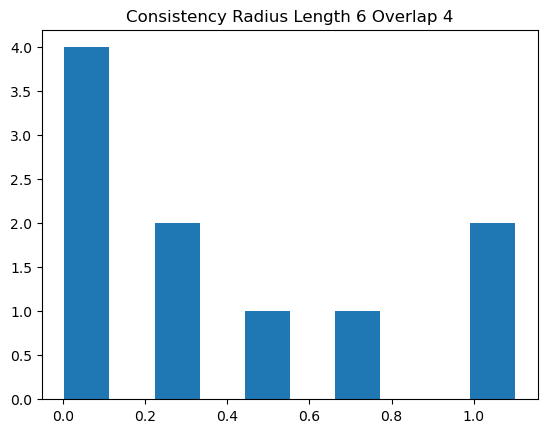

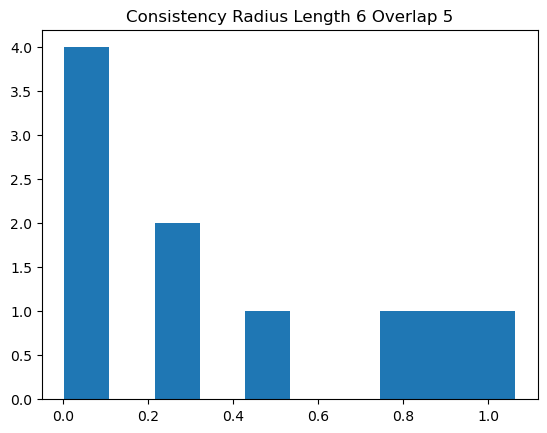

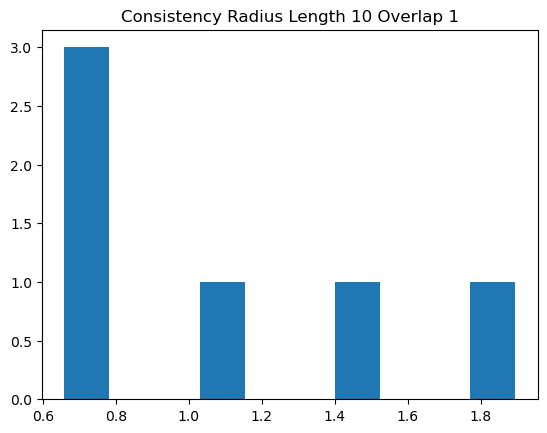

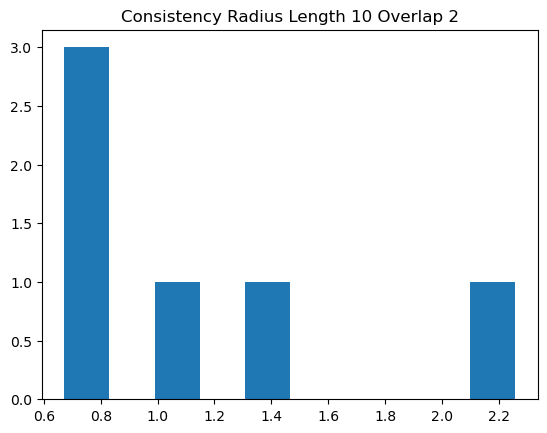

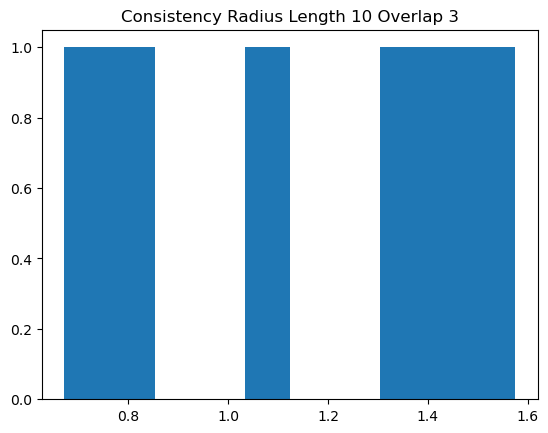

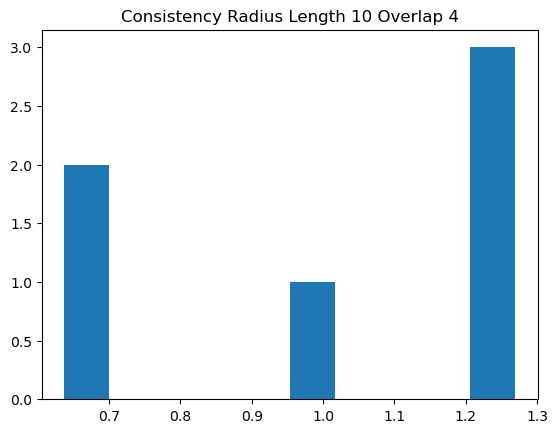

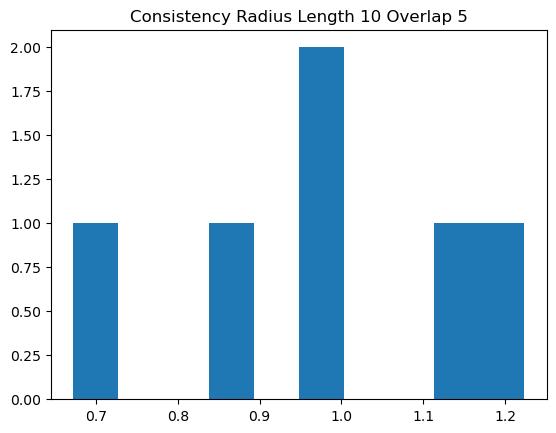

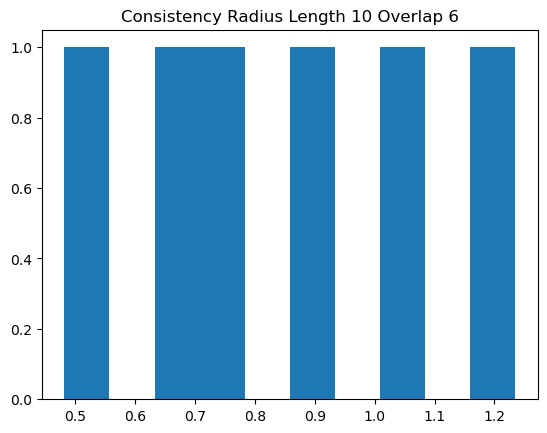

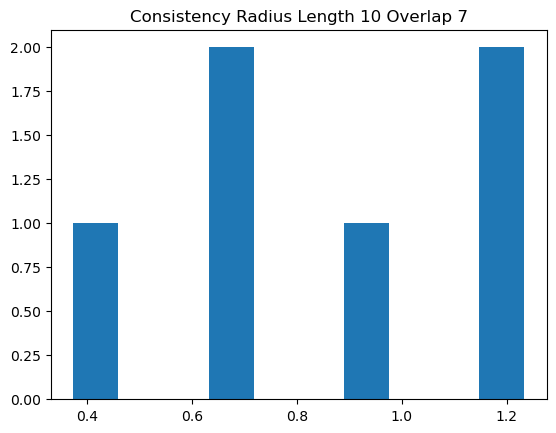

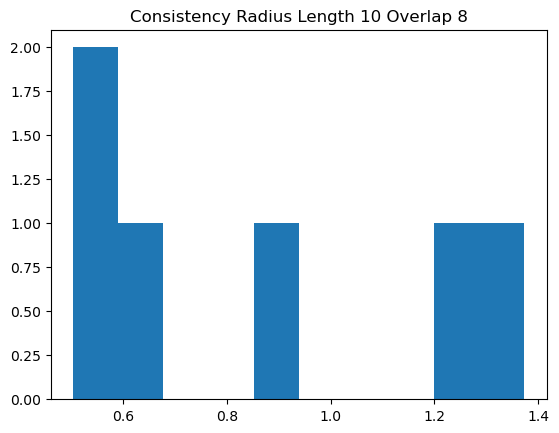

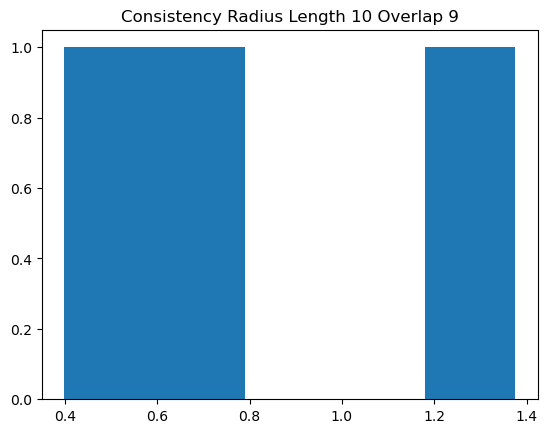

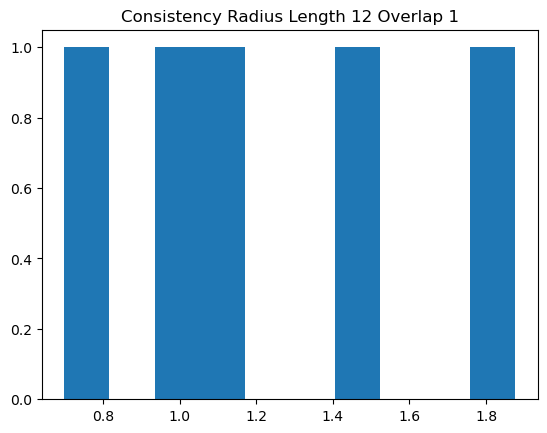

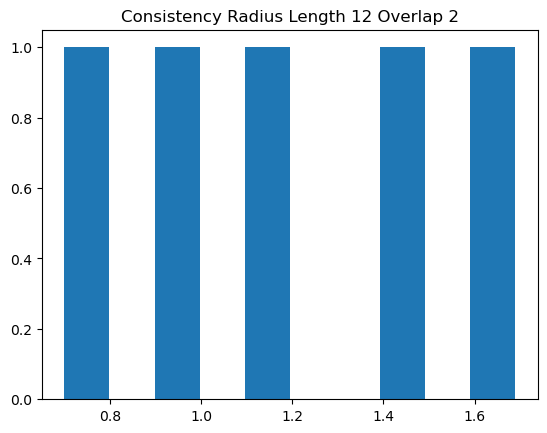

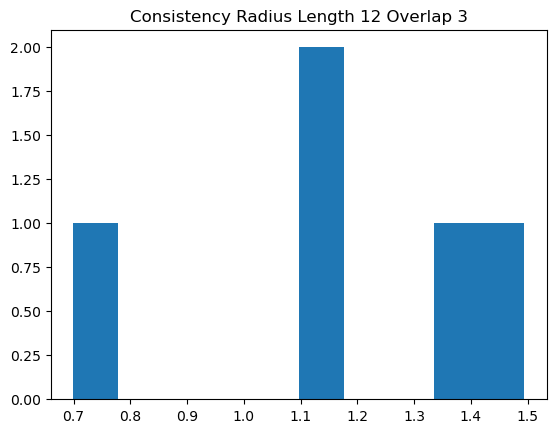

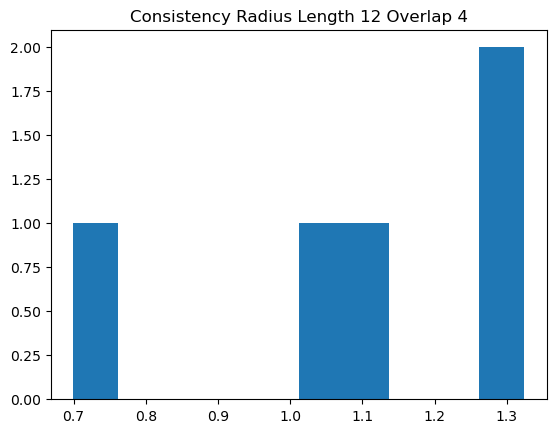

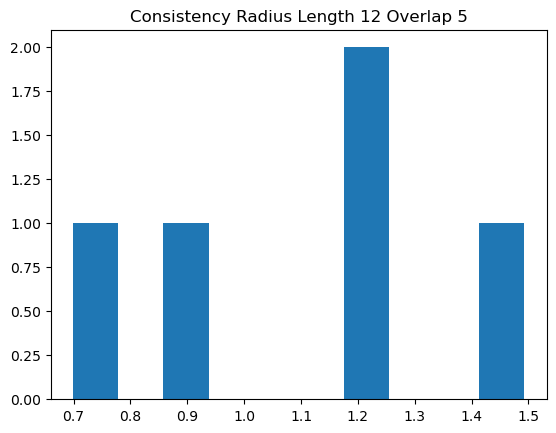

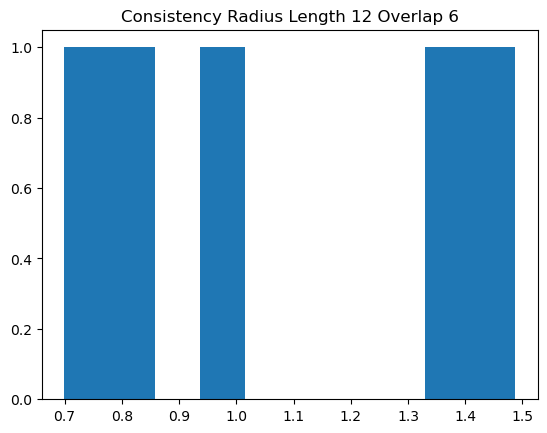

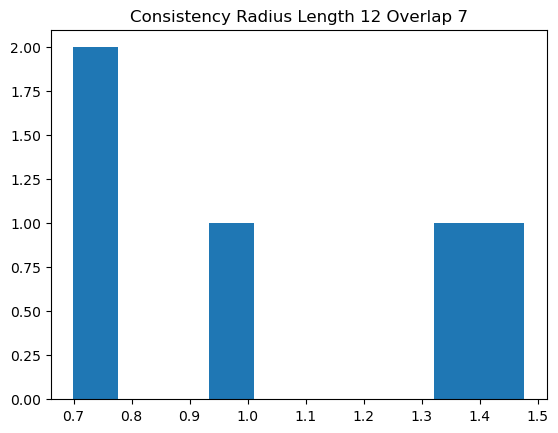

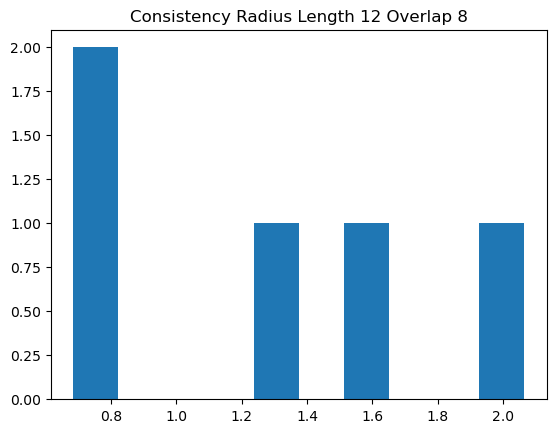

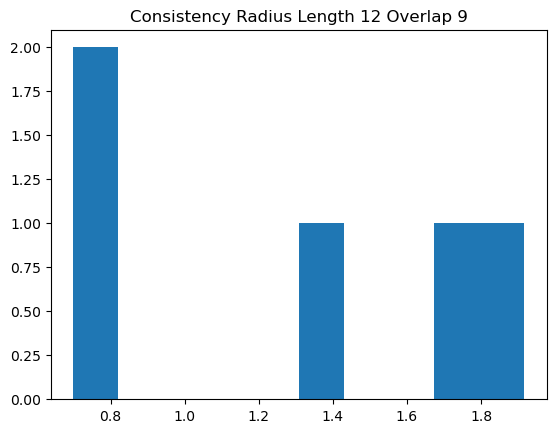

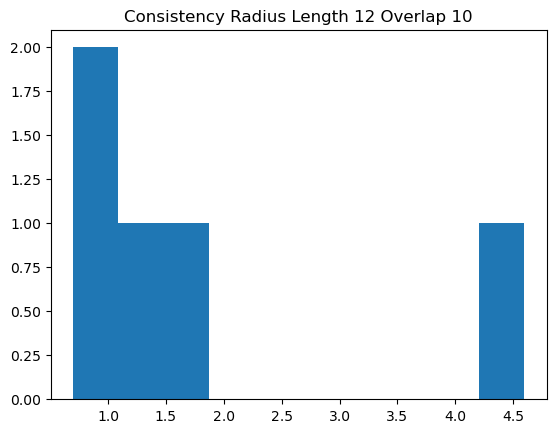

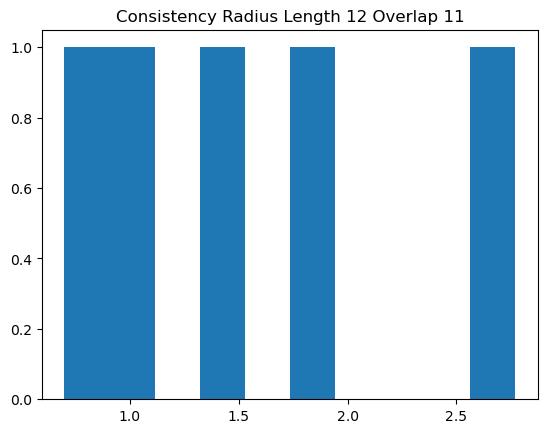

In [28]:

lengths = [2, 3, 5, 6, 10, 12]


for l in lengths: 
    for o in list(range(1,12)):  
        if o == l:
            break
        else: 
            from enum import Enum
            
            class CellConstraintType(Enum):
                EQUALITY = 0
                INEQUALITY = 1
            
            ps.CellConstraintType = CellConstraintType
            
            consistency_radius = []
            
            overlap = o     # how many years the sheaf overlap 
            length = l     # how many years long is each sheaf 
            origin_year = 1959   # year data starts 
            final_year = 2019
            n_sheafs = int((final_year - origin_year) / length) # number of sheafs 
                
            for n in range(0, n_sheafs): 
                if n == 0:
                    startyear = origin_year 
                else: 
                    startyear = origin_year + (10 * n) + overlap
                
                endyear = startyear + length 
                npts = endyear - startyear + 1   # has to be endyear - startyear + 1 
                ar = 0
                shf = netlist_sheaf.NetlistSheaf(parts,nets,npts=npts,ar=ar,lag_fcn=lag_fcn)
                
                measurements = defaultdict(list)
                with open('/Users/trixiesouthwood/Downloads/research/log_isle_royal_data.csv') as fp:
                    reader = csv.DictReader(fp, delimiter = ',')
                    idx = 0
                    for row in reader:
                        for data_name,sheaf_name in names_dict.items():
                            if row[data_name] != 'NA':
                                year = origin_year + idx 
                                if year > endyear:
                                    break 
                                        
                            if year >= startyear: 
                                
                                    datum = str(year) + "-" + sheaf_name
                                    value = float(row[data_name])
                    
                                    measurements[sheaf_name].append((year,value))
                                    
                                    shf.AddCell(datum, ps.Cell('datum',dataDimension=1))
                                    shf.GetCell(datum).SetDataAssignment(ps.Assignment('datum', np.array([value])))
                                    shf.AddCoface(sheaf_name,datum,
                                                  ps.Coface('net','datum', lambda x,i  = year - startyear: x[i] ))
                            
                        idx = idx + 1
                
                # Load in DSEM predictions
                dsem_values = defaultdict(list)
                with open('/Users/trixiesouthwood/Downloads/research/wolf_moose_dsem.csv') as fp:   
                    reader = csv.DictReader(fp, delimiter = ',')
                    idx = 0
                    for row in reader:
                        for data_name,sheaf_name in names_dict.items():
                            if row[data_name] != 'NA':
                                year = origin_year + idx 
                                
                                if year > endyear:
                                    break 
                            
                                if year >= startyear: 
                
                                    datum = str(year) + "-" + sheaf_name
                                    value = float(row[data_name])
                    
                                    dsem_values[sheaf_name].append((year,value))        
                       
                        idx = idx + 1
            
            
                for c in shf.GetCellIndexList():
                    shf.MaximallyExtendCell(c)
                
    
                shf.FuseAssignment()
                
                consistency_radius.append(shf.ComputeConsistencyRadius())
                
                years=[startyear + year for year in range(npts)]
            

        # add subplots 
        plt.hist(consistency_radius) 
        plt.title(f"Consistency Radius Length {l} Overlap {o}")
        plt.show()
        
                        
                
                


[12]